# ESc1 signal EDA — training data only

All diagnostics below use the complete training portion, indexed by `msgStamp`. The final 20% of the labeled **elapsed time span** is reserved before any EDA. There is no row subsampling.

Earlier notebook versions inspected the full dataset. This split is excluded from this run and future model selection, but is not a retrospectively pristine holdout. Correlations and serial-correlation tests are descriptive, not evidence of out-of-sample predictability.

All diagnostics, full coverage and exception tables, package versions, and interpretation are kept in this notebook. Only the split boundaries are saved separately, in `splits.json` at the repository root.

In [1]:
from pathlib import Path
import json, os, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
from scipy.cluster.hierarchy import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'takehome').exists())
sys.path.insert(0, str(ROOT / 'src'))
from takehome.data import column_coverage, training_data
from takehome.plots import heatmap
from takehome.eda import (
    acf_matrix, autocorrelation_table, bell_shape_table, correlation_clustering,
    correlation_to_column, infer_feature_cols, monthly_shift_scores, redundant_pairs,
)

DATA_PATH = Path(os.environ.get('DATA_PATH', ROOT / 'ESc1_signal_components_5min (6).parquet'))
SCATTER_N_FEATURES = 9  # Limit displayed columns, never observations.
ACF_LAG, SEASONAL_NLAGS = 15, 288

## 0. Load, set msgStamp index, reserve the test span

Let `first` and `last` be the first and last non-null `ret_5m` timestamps. The boundary is `first + 0.8 * (last - first)`. Training is `[first, boundary)` and the reserved test block is `[boundary, last]`. This is a time split, so row percentages need not equal 80/20. Outside-span unlabeled rows are excluded; internal missing observations are retained.

In [2]:
raw = pd.read_parquet(DATA_PATH)
if raw.index.name and raw.index.name not in raw.columns:
    raw = raw.reset_index()
raw = raw.set_index('msgStamp')
if not isinstance(raw.index, pd.DatetimeIndex):
    if pd.api.types.is_numeric_dtype(raw.index.dtype):
        raise ValueError('Numeric msgStamp: specify its epoch unit explicitly before converting.')
    raw.index = pd.to_datetime(raw.index, errors='raise')
raw = raw.sort_index()
df, split = training_data(raw)
del raw  # Do not retain a full-sample frame for later cells to accidentally use.

assert df.index.name == 'msgStamp'
assert len(df) == split['train_rows'] and df.index.max() < split['cutoff']
print(split.to_string())
print(f'Training timestamps: {df.index.min()} through {df.index.max()}')
(ROOT / 'splits.json').write_text(json.dumps(split.to_dict(), default=str, indent=2))
feature_cols = infer_feature_cols(df)
price_col, cashflow_col, time_col = 'adjMid', 'cashflow', 'msgStamp'
print(f'Training shape: {df.shape}; features: {len(feature_cols)}')
display(df.head())

first_label               2014-01-02 06:05:00-05:00
cutoff                    2022-07-14 00:33:00-04:00
last_label                2024-08-30 16:55:00-04:00
train_rows                                   640734
test_rows                                    160325
train_fraction_of_time                          0.8
Training timestamps: 2014-01-02 06:05:00-05:00 through 2022-07-14 00:30:00-04:00
Training shape: (640734, 105); features: 99


,trade_date,wmid,adjMid,volume,cashflow,ret_5m,x1,x2,x3,x4,...,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99
msgStamp,,,,,,,,,,,,,,,,,,,,,
2014-01-02 06:05:00-05:00,2014-01-02,1836.844118,2008.598998,17893.0,1836.0,-0.000680,-0.000189,-0.000143,-0.000093,0.000485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-02 06:10:00-05:00,2014-01-02,1835.672917,2007.232232,3809.0,-961.0,0.000409,-0.000308,-0.000268,-0.000200,-0.000034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-02 06:15:00-05:00,2014-01-02,1836.407635,2008.052291,3328.0,-187.0,0.000136,-0.001099,-0.000780,-0.000550,-0.000549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-02 06:20:00-05:00,2014-01-02,1836.811905,2008.325645,2498.0,300.0,0.000681,-0.001608,-0.001347,-0.001034,-0.000054,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-02 06:25:00-05:00,2014-01-02,1838.159786,2009.692410,2528.0,-369.0,0.000952,-0.001579,-0.001705,-0.001486,0.000182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Per-column coverage — training data only

First and last **non-null msgStamp** for every column, non-null count, and percentage of training rows that are null. Entirely missing columns remain visible with `NaT` bounds. No test-period distribution statistics are computed.

In [3]:
coverage = column_coverage(df)
with pd.option_context('display.max_rows', None):
    display(coverage)

,first_valid,last_valid,non_null,null_pct
column,,,,
trade_date,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,640734,0.000000
wmid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
adjMid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
volume,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
cashflow,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
ret_5m,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,590635,7.819001
x1,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x2,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x3,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793


## 1. Scatter matrix

Nine representative feature columns are shown for readability, using **all their training observations**. Missing pairs are omitted by the plotting routine; rows are not sampled. The all-feature correlation matrix below covers all feature pairs.

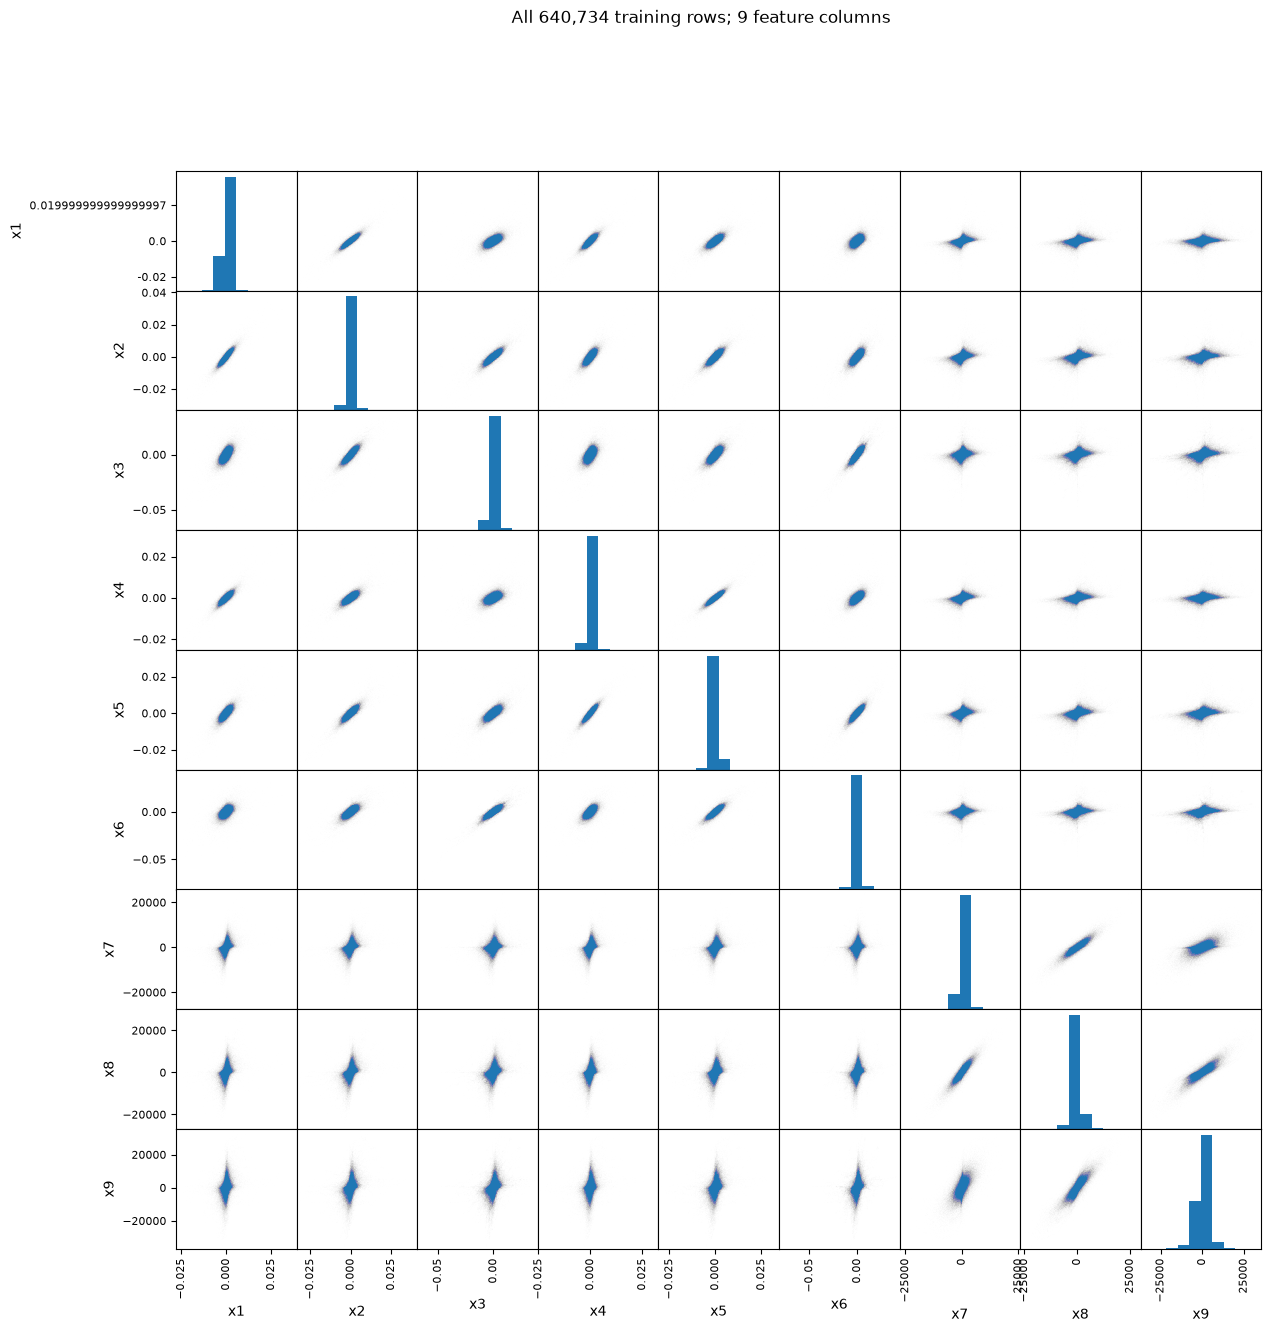

In [4]:
scatter_features = [c for c in feature_cols if df[c].nunique() > 1][:SCATTER_N_FEATURES]
scatter_matrix(df[scatter_features], figsize=(14, 14), diagonal='hist',
               alpha=.08, s=.2, rasterized=True)
plt.suptitle(f'All {len(df):,} training rows; {len(scatter_features)} feature columns', y=.995)
plt.show()
plt.close('all')

## 2. Distribution-shape screen and return sanity check

No Gaussianity test. The full-sample screen flags a dip statistic above 0.01, absolute Bowley quartile skew above 0.25, an exact point mass above 10%, or fewer than 20 unique values. These are practical degeneracy thresholds, not calibrated hypothesis tests; a pass does not prove a bell shape. High kurtosis is deliberately allowed.

Using the [Hartigan dip statistic](https://github.com/RUrlus/diptest) rather than its iid p-value avoids both a sample cap and interpreting tiny large-sample departures as useful rejections. Serially dependent features are not iid.

`adjMid.pct_change(fill_method=None)` is a contemporaneous sanity check. The supplied `ret_5m` is also reported separately; its alignment is not assumed to match that price change. All values and sample counts below are training-only.

,feature,n,nunique,max_mass,robust_skew,dip_stat,bell_like
6,x7,346261,345026,0.002940,0.065775,inf,False
68,x69,9126,9126,0.000110,-0.019220,0.002129,True
66,x67,9126,9126,0.000110,-0.012363,0.001646,True
67,x68,9126,9126,0.000110,-0.059021,0.001637,True
11,x12,16560,16560,0.000060,-0.036038,0.001600,True
...,...,...,...,...,...,...,...
56,x57,480744,480744,0.000002,-0.010753,0.000172,True
58,x59,338841,338841,0.000003,0.024714,0.000165,True
40,x41,446749,446749,0.000002,-0.029800,0.000164,True
54,x55,480744,480744,0.000002,0.037573,0.000145,True


Pass shape screen: 98/99; flagged: 1


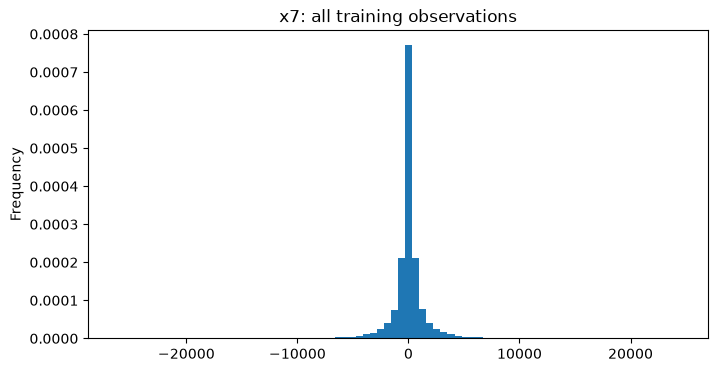

,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
60,x61,0.415557,0.000000e+00,0.350083,0.000000e+00,168937,0.000000e+00,0.000000e+00,0.415557
57,x58,-0.411100,0.000000e+00,-0.337529,0.000000e+00,338832,0.000000e+00,0.000000e+00,0.411100
42,x43,0.381231,0.000000e+00,0.313393,0.000000e+00,168935,0.000000e+00,0.000000e+00,0.381231
36,x37,0.351904,0.000000e+00,0.295867,0.000000e+00,168823,0.000000e+00,0.000000e+00,0.351904
45,x46,0.345192,0.000000e+00,0.282360,0.000000e+00,99355,0.000000e+00,0.000000e+00,0.345192
33,x34,0.332063,0.000000e+00,0.264749,0.000000e+00,161112,0.000000e+00,0.000000e+00,0.332063
9,x10,0.286760,6.345562e-311,0.328594,0.000000e+00,16560,1.396024e-310,0.000000e+00,0.328594
66,x67,0.321950,4.098448e-219,0.314194,3.150248e-208,9126,7.955811e-219,6.497386e-208,0.321950
51,x52,0.319535,0.000000e+00,0.285254,0.000000e+00,167411,0.000000e+00,0.000000e+00,0.319535
18,x19,0.315361,0.000000e+00,0.261706,0.000000e+00,163843,0.000000e+00,0.000000e+00,0.315361


Top correlations to supplied ret_5m (not assumed contemporaneous):


,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
57,x58,0.018288,1.831179e-26,0.025212,9.105777e-49,338777,1.812867e-24,9.014720e-47,0.025212
6,x7,-0.001722,3.108236e-01,-0.023301,8.598336e-43,346205,4.215279e-01,2.128088e-41,0.023301
9,x10,-0.007924,3.078746e-01,-0.021978,4.678876e-03,16560,4.215279e-01,8.577939e-03,0.021978
39,x40,-0.001265,3.978454e-01,-0.021057,5.449059e-45,446673,5.062010e-01,1.798190e-43,0.021057
33,x34,-0.020514,1.799257e-16,-0.016435,4.186711e-11,161114,5.937549e-15,2.590528e-10,0.020514
54,x55,-0.000528,7.141038e-01,-0.020364,2.843706e-45,480723,7.684378e-01,1.407634e-43,0.020364
12,x13,-0.003123,2.229217e-01,-0.019904,7.865186e-15,152348,3.448319e-01,7.612521e-14,0.019904
15,x16,-0.002247,3.805279e-01,-0.019792,1.111916e-14,152348,4.956877e-01,9.173306e-14,0.019792
60,x61,-0.018851,9.356760e-15,-0.018883,8.458357e-15,168885,1.852638e-13,7.612521e-14,0.018883
34,x35,-0.018762,5.022619e-14,-0.007524,2.527138e-03,161114,8.287321e-13,4.811282e-03,0.018762


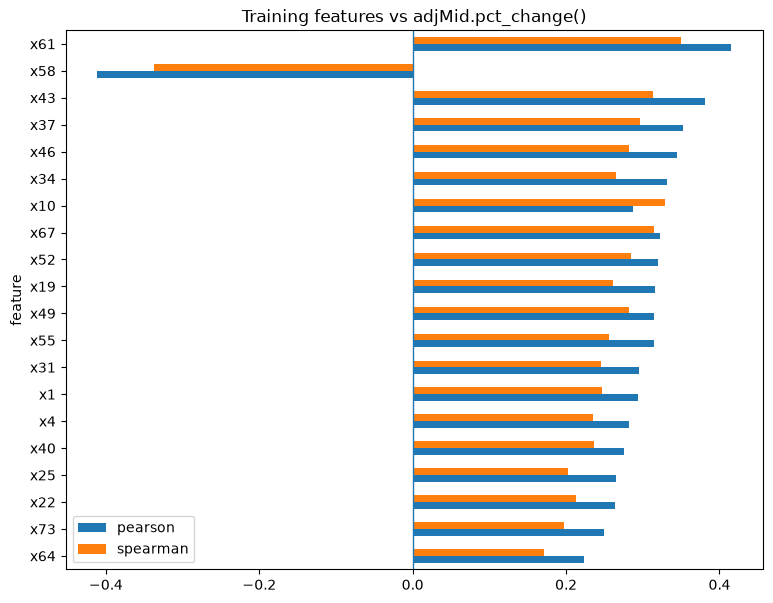

In [5]:
shape = bell_shape_table(df, feature_cols)
flagged_shape = shape.loc[~shape.bell_like]
display(shape)
print(f'Pass shape screen: {shape.bell_like.sum()}/{len(shape)}; flagged: {len(flagged_shape)}')
assert shape.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
for col in flagged_shape.feature.head(6):
    df[col].plot.hist(bins=80, density=True, figsize=(8, 4), title=f'{col}: all training observations')
    plt.show()
    plt.close('all')

df['_ret1'] = df.adjMid.pct_change(fill_method=None)
return_corr = correlation_to_column(df, '_ret1', feature_cols)
provided_corr = correlation_to_column(df, 'ret_5m', feature_cols)
strong_target = return_corr.loc[return_corr.max_abs_corr >= .10]
display(strong_target)
print('Top correlations to supplied ret_5m (not assumed contemporaneous):')
display(provided_corr.head(15))
return_corr.head(20).sort_values('max_abs_corr').plot.barh(
    x='feature', y=['pearson', 'spearman'], figsize=(9, 7),
    title='Training features vs adjMid.pct_change()')
plt.axvline(0, linewidth=1)
plt.show()
plt.close('all')

## 3. Feature correlation and dendrogram

Cluster using distance $1-|\rho_S|$ so strongly positive and strongly negative variants are grouped together. The heatmap retains signed Spearman correlation.

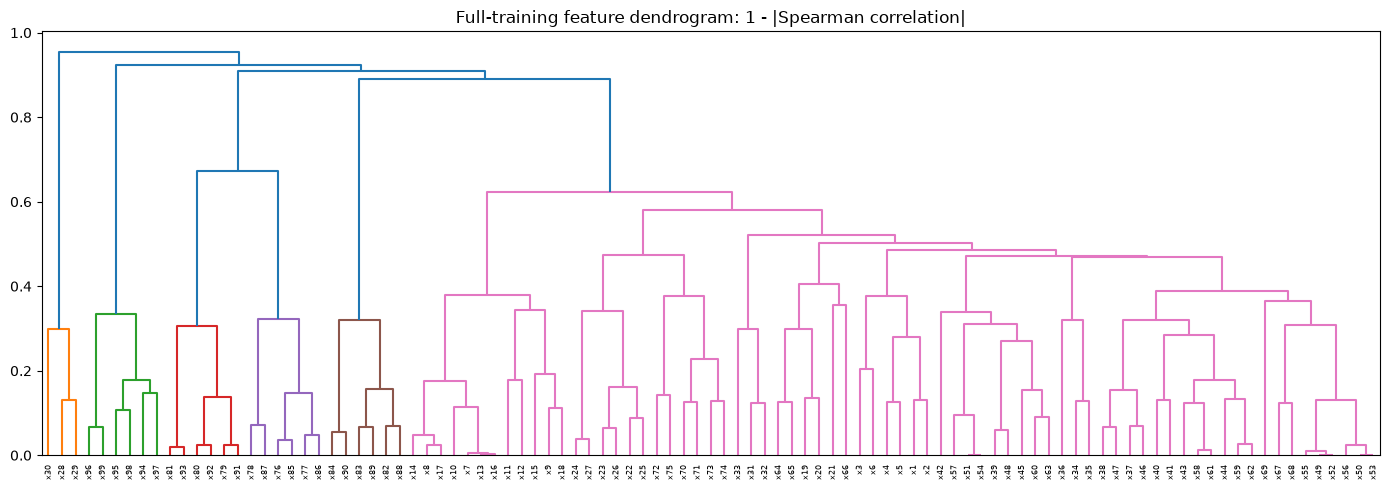

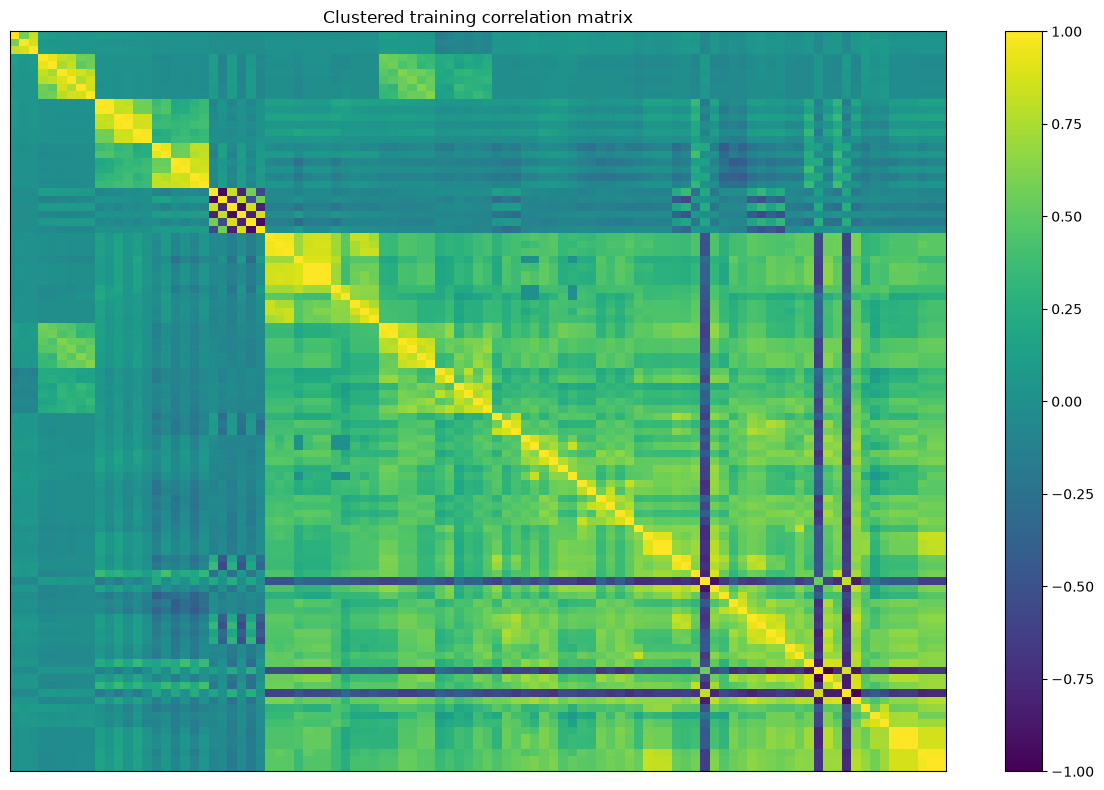

,feature1,feature2,corr,abs_corr,index_gap
0,x49,x52,0.999996,0.999996,3
1,x50,x53,0.999857,0.999857,3
2,x51,x54,0.999642,0.999642,3
3,x13,x16,0.997249,0.997249,3
4,x7,x16,0.994874,0.994874,9
5,x7,x13,0.994009,0.994009,6
6,x49,x55,0.988759,0.988759,6
7,x52,x55,0.988740,0.988740,3
8,x58,x61,-0.987044,0.987044,3
9,x81,x93,0.981349,0.981349,12


,n_pairs,median_abs_corr,p90_abs_corr,frac_gt_080
index_gap,,,,
1,98,0.818814,0.872799,0.642857
3,96,0.630711,0.941085,0.229167
2,97,0.558947,0.767274,0.072165
6,93,0.493151,0.850941,0.107527
30,69,0.482934,0.579723,0.000000
12,87,0.479111,0.719442,0.034483
9,90,0.473028,0.793256,0.100000
21,78,0.463799,0.634150,0.038462
18,81,0.459806,0.680542,0.037037


,count,mean,median
same_mod3,,,
False,3267,0.283545,0.285312
True,1584,0.344879,0.387690


In [6]:
corr, z, order = correlation_clustering(df, feature_cols, method='spearman')
plt.figure(figsize=(14, 5))
dendrogram(z, labels=feature_cols, leaf_rotation=90, leaf_font_size=6)
plt.title('Full-training feature dendrogram: 1 - |Spearman correlation|')
plt.tight_layout()
plt.show()
plt.close('all')
heatmap(corr.loc[order, order], 'Clustered training correlation matrix', labels=False, limits=(-1, 1))
plt.close('all')
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs = redundant_pairs(corr, threshold=.8)
display(pairs.head(30))
gap_pairs = pairs.dropna(subset=['index_gap']).copy()
gap_pairs['index_gap'] = gap_pairs.index_gap.astype(int)
all_pairs = redundant_pairs(corr, threshold=0).dropna(subset=['index_gap'])
all_pairs['index_gap'] = all_pairs.index_gap.astype(int)
gap_summary = all_pairs.groupby('index_gap').agg(
    n_pairs=('abs_corr', 'size'), median_abs_corr=('abs_corr', 'median'),
    p90_abs_corr=('abs_corr', lambda x: x.quantile(.9)),
    frac_gt_080=('abs_corr', lambda x: (x >= .8).mean()),
).sort_values('median_abs_corr', ascending=False)
all_pairs['same_mod3'] = all_pairs.index_gap.mod(3).eq(0)
mod3_summary = all_pairs.groupby('same_mod3').abs_corr.agg(['count', 'mean', 'median'])
display(gap_summary.head(20), mod3_summary)

## 4. Full-training autocorrelation

Ljung–Box(15) is applied directly to each feature, not regression residuals. Display and rank raw statistics, ACF(1), and per-feature observation counts; Q also grows with sample size. Missing values are omitted per feature: these are lags between successive observed values, not guaranteed five-minute clock intervals.

,feature,n,acf1,max_abs_acf_1_to_lag,lb_stat,lb_pvalue,lb_qvalue
56,x57,480744,0.989220,0.989220,4.578699e+06,0.0,0.0
41,x42,446749,0.989065,0.989065,4.307341e+06,0.0,0.0
65,x66,374281,0.988780,0.988780,3.650854e+06,0.0,0.0
77,x78,338776,0.990617,0.990617,3.395004e+06,0.0,0.0
5,x6,329833,0.987226,0.987226,3.214314e+06,0.0,0.0
2,x3,333875,0.987453,0.987453,3.203368e+06,0.0,0.0
59,x60,338841,0.986322,0.986322,3.135615e+06,0.0,0.0
8,x9,346261,0.976988,0.976988,2.935727e+06,0.0,0.0
55,x56,480744,0.963029,0.963029,2.612777e+06,0.0,0.0
40,x41,446749,0.963445,0.963445,2.431948e+06,0.0,0.0


Usable features: 99/99
Ljung-Box(15), FDR q<5%: 99/99


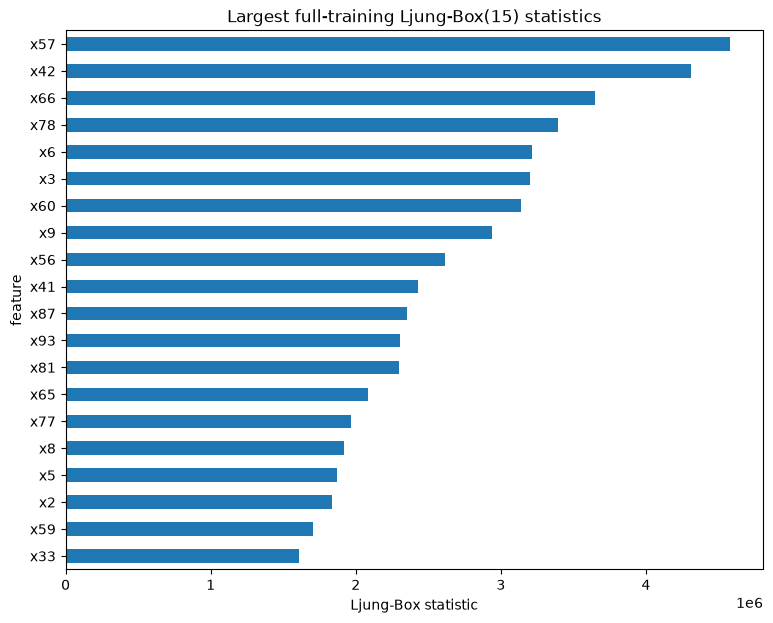

In [7]:
auto = autocorrelation_table(df, feature_cols, lag=ACF_LAG)
assert auto.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
display(auto.head(20))
print(f'Usable features: {auto.lb_stat.notna().sum()}/{len(auto)}')
print(f'Ljung-Box({ACF_LAG}), FDR q<5%: {(auto.lb_qvalue < .05).sum()}/{len(auto)}')
auto.head(20).sort_values('lb_stat').plot.barh(
    x='feature', y='lb_stat', figsize=(9, 7), legend=False,
    title=f'Largest full-training Ljung-Box({ACF_LAG}) statistics')
plt.xlabel('Ljung-Box statistic')
plt.show()
plt.close('all')

### 4.1 Longer-lag / seasonal ACF patterns

Repeated bands or peaks in the heatmap flag periodic structure. These are **row lags**: if source bars have gaps, lag 288 is not automatically a 24-hour clock-time lag.

,peak_lag,peak_acf
x30,16,0.624285
x18,16,0.618594
x78,16,0.607077
x87,16,0.605638
x33,16,0.591339
x6,16,0.591328
x84,16,0.589893
x93,16,0.589365
x66,16,0.588983
x81,16,0.585701


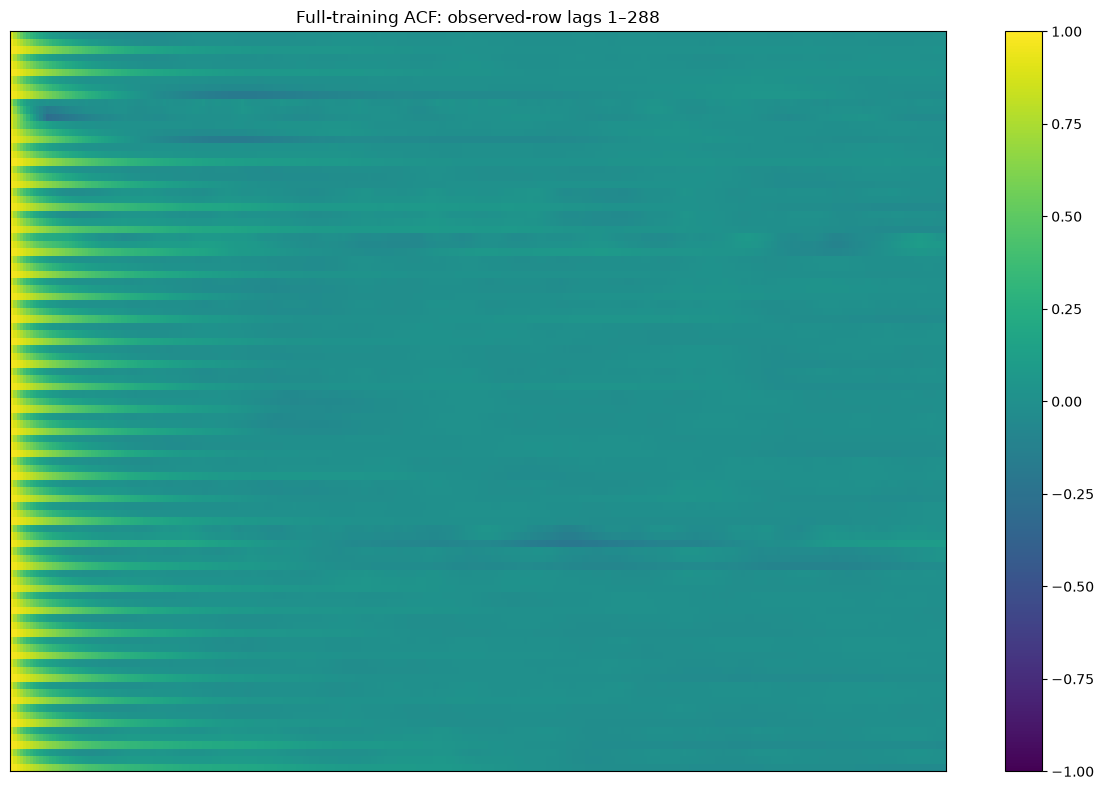

In [8]:
season_acf = acf_matrix(df, feature_cols, nlags=SEASONAL_NLAGS)
long_lag = season_acf.loc[ACF_LAG + 1:]
valid = long_lag.columns[long_lag.notna().any()]
peak_lag = long_lag[valid].abs().idxmax()
peak = pd.DataFrame({
    'peak_lag': peak_lag,
    'peak_acf': [long_lag.loc[peak_lag[c], c] for c in valid],
}).sort_values('peak_acf', key=lambda s: s.abs(), ascending=False)
display(peak.head(20))
heatmap(season_acf.loc[1:].T, 'Full-training ACF: observed-row lags 1–288', labels=False, limits=(-1, 1))
plt.close('all')

## 5. Training-period distribution shifts

Adjacent-month mean changes are scaled by the **training** standard deviation. The log standard-deviation ratio compares adjacent months. These are descriptive changes, not formal break-date estimates. All grouping now uses `msgStamp`; partial boundary months can have fewer observations.

,max_abs_monthly_mean_shift_z,max_abs_monthly_log_std_ratio
x27,1.194728,1.544659
x24,1.163821,1.561496
x99,1.127276,1.652901
x96,1.091659,1.706036
x30,1.075000,2.899247
x33,1.064781,1.325685
x39,1.005112,1.154962
x63,0.966948,1.200168
x36,0.896158,1.049421
x29,0.888844,2.891253


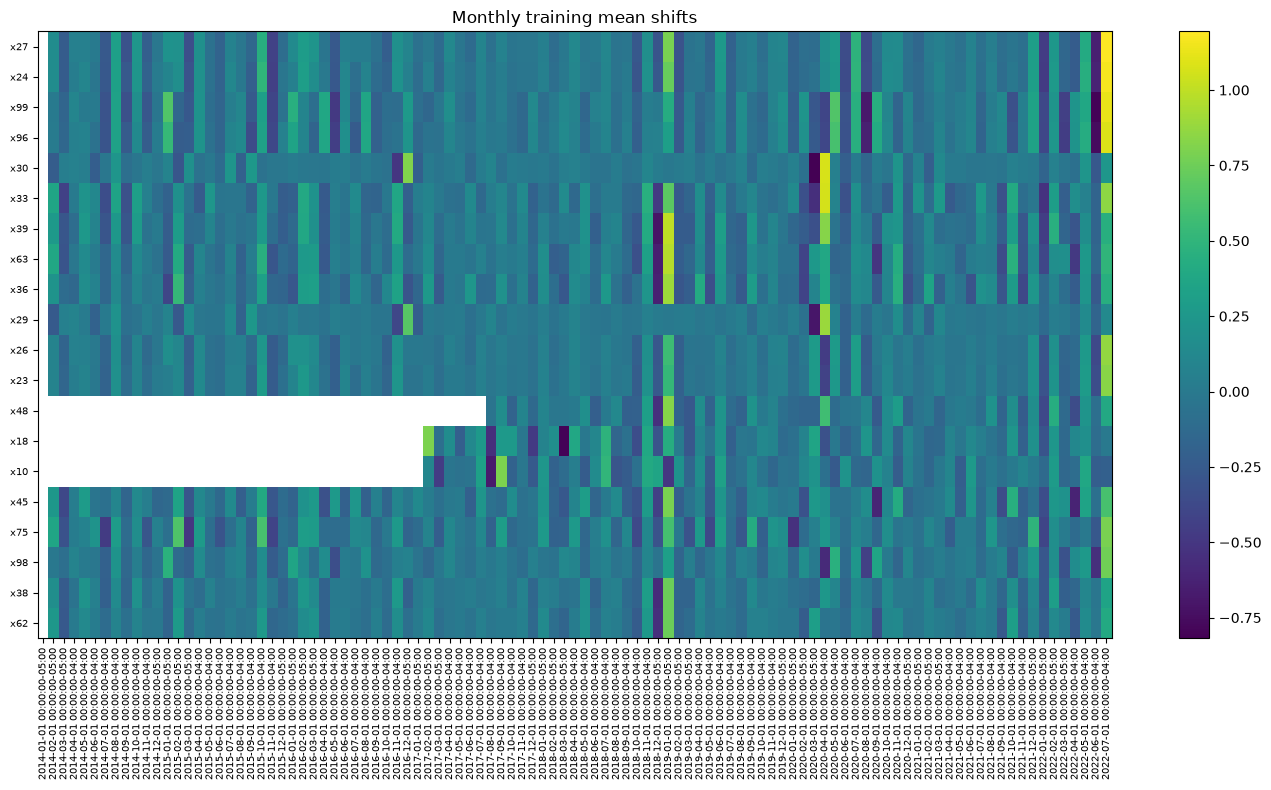

In [9]:
mean_shift, vol_shift = monthly_shift_scores(df.reset_index(), 'msgStamp', feature_cols)
breaks = pd.DataFrame({
    'max_abs_monthly_mean_shift_z': mean_shift.abs().max(),
    'max_abs_monthly_log_std_ratio': vol_shift.abs().max(),
}).sort_values('max_abs_monthly_mean_shift_z', ascending=False)
display(breaks.head(20))
heatmap(mean_shift[breaks.head(20).index].T, 'Monthly training mean shifts', figsize=(14, 8))
plt.close('all')

## 6. Cashflow: infer the definition from named fields

Only named numeric market variables are compared; `x*` features are deliberately excluded. Examine cashflow relative to volume as well as unconditional level correlations.

,wmid,adjMid,volume,cashflow,ret_5m
wmid,1.000000,0.999182,0.052109,0.008949,0.002637
adjMid,0.999182,1.000000,0.054724,0.008655,0.002669
volume,0.052109,0.054724,1.000000,-0.013539,0.008276
cashflow,0.008949,0.008655,-0.013539,1.000000,-0.016442
ret_5m,0.002637,0.002669,0.008276,-0.016442,1.000000


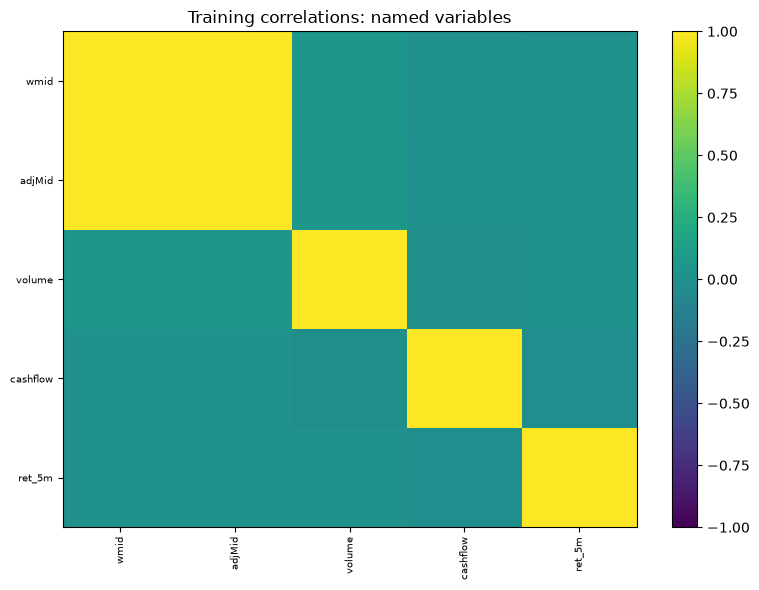

,spearman
adjMid,0.008655
wmid,0.008949
volume,-0.013539
ret_5m,-0.016442


In [10]:
named_numeric = [c for c in df.select_dtypes(include=np.number).columns
                 if c not in feature_cols and not c.startswith('_')]
named_corr = df[named_numeric].corr(method='spearman')
display(named_corr)
heatmap(named_corr, 'Training correlations: named variables', figsize=(8, 6), limits=(-1, 1))
plt.close('all')
cash_named = named_corr['cashflow'].drop('cashflow').sort_values(key=lambda x: x.abs()).to_frame('spearman')
display(cash_named)

### Cashflow-to-volume exceptions

Show rows where `abs(cashflow / volume) > 1`. Zero volume is not silently discarded: nonzero cashflow divided by zero appears as infinity and is included by this predicate. The complete named-variable exception table is displayed below, without row truncation. No CSV is exported.

In [11]:
flow_ratio = df.cashflow / df.volume
cashflow_outliers = df.loc[flow_ratio.abs().gt(1), named_numeric].assign(cashflow_per_volume=flow_ratio)
print(f'{len(cashflow_outliers):,} / {len(df):,} training rows have |cashflow / volume| > 1')
print(f'Zero-volume rows: {df.volume.eq(0).sum():,}')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(cashflow_outliers)

551 / 640,734 training rows have |cashflow / volume| > 1
Zero-volume rows: 6,471


,wmid,adjMid,volume,cashflow,ret_5m,cashflow_per_volume
msgStamp,,,,,,
2014-03-17 00:00:00-04:00,1833.603659,2012.501872,671.0,827.0,-0.000273,1.232489
2014-03-17 18:20:00-04:00,1851.981405,2032.530862,187.0,-294.0,-0.000135,-1.572193
2014-03-17 19:50:00-04:00,1852.390625,2032.805231,178.0,-247.0,-0.000270,-1.387640
2014-03-17 19:55:00-04:00,1851.705357,2032.256492,311.0,526.0,NaN,1.691318
2014-03-18 01:00:00-04:00,1852.914692,2033.353971,32.0,-51.0,0.000000,-1.593750
2014-03-18 01:10:00-04:00,1852.589286,2033.353971,33.0,-37.0,0.000135,-1.121212
2014-03-18 02:50:00-04:00,1850.055336,2030.335904,168.0,-192.0,0.000000,-1.142857
2014-03-18 19:00:00-04:00,1862.907895,2044.603129,34.0,-100.0,0.000000,-2.941176
2014-03-19 20:30:00-04:00,1851.707317,2032.256492,99.0,101.0,-0.000270,1.020202


### Volatility-scaled signed-flow diagnostic

**Working hypothesis:** cashflow is likely signed trade flow or quote imbalance, rather than an unsigned price-times-volume cash amount. This is a hypothesis, not a documented definition. Out-of-range ratios can also reflect unit, aggregation, or timestamp mismatches.

The expression below is the requested calculation. It clips the ratio to [-1, 1], scales by the previous row's EWM return standard deviation (`halflife=288*21`, pandas defaults), multiplies by the supplied return, then sums by calendar day and cumulatively. All state is learned inside training. Initial undefined volatility/contributions remain missing; pandas daily `sum()` uses its default behavior.

This curve is exploratory, not a validated strategy: the alignment of `ret_5m` with contemporaneous cashflow is unverified, and there are no execution delays or costs. Only the volatility denominator is lagged.

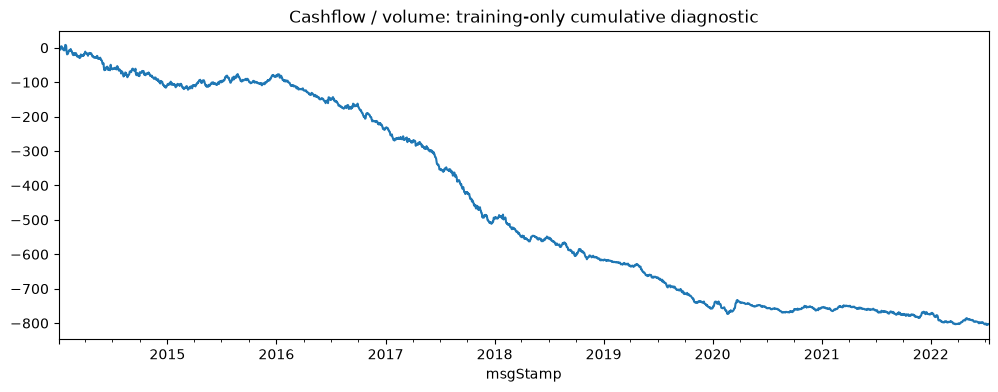

In [12]:
(df['cashflow'] / df['volume']).clip(-1, 1).div(
    df['ret_5m'].ewm(halflife=288*21).std().shift()
).mul(df['ret_5m']).resample('D').sum().cumsum().plot(
    figsize=(12, 4), title='Cashflow / volume: training-only cumulative diagnostic'
)
plt.show()
plt.close('all')

# Retain the same calculation for the summary and reproducibility checks.
flow_contribution = flow_ratio.clip(-1, 1).div(
    df.ret_5m.ewm(halflife=288*21).std().shift()
).mul(df.ret_5m)
flow_cumulative = flow_contribution.resample('D').sum().cumsum()

# Standalone feature importance

Assess each signal on its own with the requested exposure $x/\sigma_x^2$. This is **standalone performance**, not its unique incremental contribution after controlling for the other, often correlated, features. No sign is flipped and no test data are accessed.

Use every training row and every `x` column. The half-life and minimum number of non-null observations are both `288*21 = 6048`. EWM uses pandas defaults (`adjust=True`, `ignore_na=False`, sample-standard-deviation estimate); the current signal is included in its own scale. Only zero-volatility divisions are changed to missing to avoid infinite positions. There is no fitted leverage cap.

Daily `sum()` is retained exactly as requested: an all-missing day (including warm-up) becomes zero. The histogram uses **unannualized calendar-day mean/std**, not annualized trading-day Sharpe. Unequal feature availability means these are not common-sample or execution-adjusted comparisons. The coverage table below makes the differing sample lengths visible.

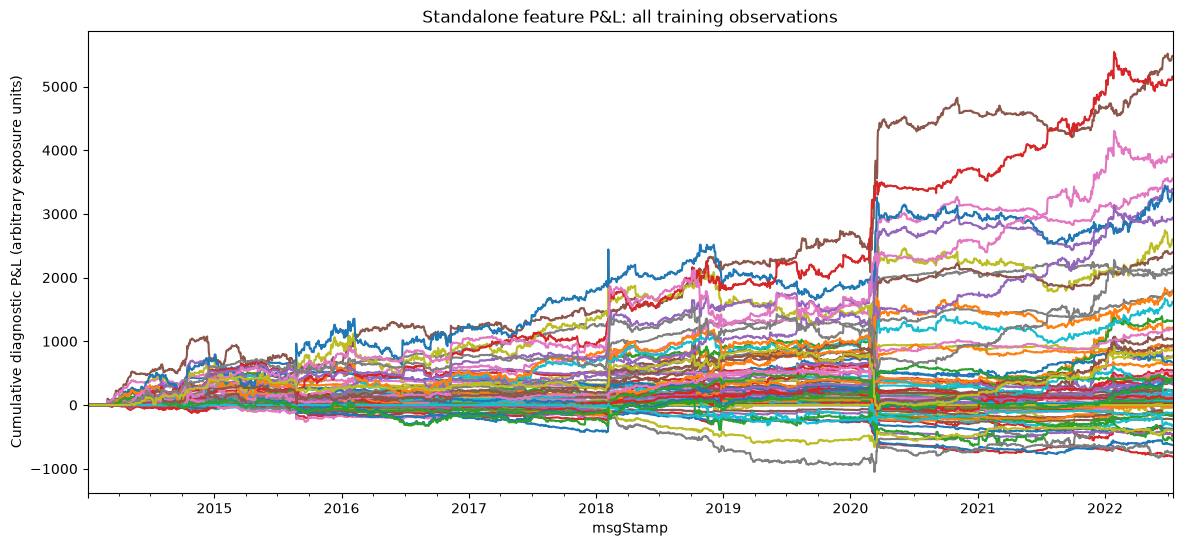

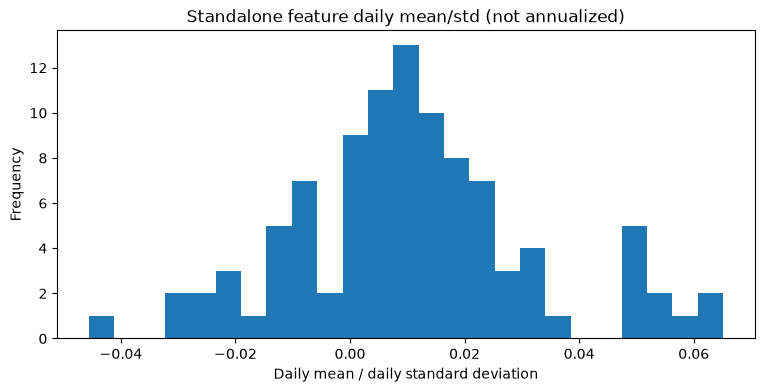

In [13]:
from takehome.features import ts_std, ts_standardize, ts_zscore, sharpe, standalone_pnl

x_cols = df.head(0).filter(like='x').columns
HL = 288 * 21
# Equivalent to x.div(ts_std(x, HL)**2), then multiply returns by ROW.
pnl = standalone_pnl(df[x_cols], df['ret_5m'], hl=HL)
pnl_daily = pnl.resample('D').sum()
assert pnl.index.equals(df.index) and pnl.columns.equals(x_cols)
assert not np.isinf(pnl.to_numpy()).any()
pnl_daily.cumsum().plot(figsize=(14, 6), legend=False,
                       title='Standalone feature P&L: all training observations')
plt.ylabel('Cumulative diagnostic P&L (arbitrary exposure units)')
plt.show()
plt.close('all')
pnl_daily.pipe(sharpe).plot.hist(bins=25, figsize=(9, 4),
                               title='Standalone feature daily mean/std (not annualized)')
plt.xlabel('Daily mean / daily standard deviation')
plt.show()
plt.close('all')

In [14]:
standalone = pd.DataFrame({
    'daily_mean_over_std': pnl_daily.pipe(sharpe),
    'pnl_observations': pnl.count(),
    'days_with_observations': pnl.notna().resample('D').sum().gt(0).sum(),
    'first_pnl_msgStamp': pnl.apply(lambda x: x.first_valid_index()),
    'last_pnl_msgStamp': pnl.apply(lambda x: x.last_valid_index()),
}).sort_values('daily_mean_over_std', ascending=False)
with pd.option_context('display.max_rows', None):
    display(standalone)
print('Best/worst standalone DAILY mean/std:',
      standalone.daily_mean_over_std.max(), standalone.daily_mean_over_std.min())

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp
x94,0.065095,153523,2064,2014-04-29 12:15:00-04:00,2022-07-13 16:00:00-04:00
x76,0.063963,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x77,0.060185,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x86,0.055775,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x78,0.053404,332667,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x85,0.051261,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x58,0.051148,332732,2163,2014-02-26 12:00:00-05:00,2022-07-13 16:00:00-04:00
x97,0.051007,147767,2058,2014-05-07 11:50:00-04:00,2022-07-13 16:00:00-04:00
x87,0.048338,228876,2146,2014-03-21 16:00:00-04:00,2022-07-13 16:00:00-04:00
x95,0.047486,153523,2064,2014-04-29 12:15:00-04:00,2022-07-13 16:00:00-04:00


Best/worst standalone DAILY mean/std: 0.06509473315642564 -0.045580108532308594


## Why feature volatility can proxy asset volatility

For a signed standardized signal, the intended idealized exposure is

$$w_{j,t}=\frac{\mathrm{ts\_standardize}(x_j)_t}{\sigma_{r,t}}
=\frac{x_{j,t}}{\sigma_{x_j,t}\,\sigma_{r,t}},\qquad
\mathrm{PnL}_{j,t}=w_{j,t}r_{t\to t+h}.$$

`ts_std(signal) / asset_vol` would be a different, unsigned exposure: it removes the direction of the signal. The expression above uses **ts_standardize**, not **ts_std**, in the numerator. Use `ts_zscore` instead only when removing the local signal mean is intentional.

Prices/realized returns are withheld in the final deployment period, so realized asset volatility cannot be refreshed there. If $\sigma_{x_j,t}\approx k_j\sigma_{r,t}$ with reasonably stable $k_j$, then $w_{j,t}\approx k_j x_{j,t}/\sigma_{x_j,t}^2$. Dropping the constant gives the requested diagnostic. This is a proxy assumption, not an identity; a changing feature amplitude, family or regime can break it. Fixed positive scale does not change mean/std but changes P&L units.

Weighting can alternatively enter the fitter. For WLS, $H=X(X^\top W X)^{-1}X^\top W$ already includes the observation weights in $\widehat y=Hy$. However, weighting historical residuals does **not automatically implement the same forecast-time inverse-volatility exposure**. Lasso does not have one fixed, response-independent hat matrix: the active set depends on the target. The initial fitter below therefore documents its weighting objective explicitly.

Only the feature history enters the signal scale. Nevertheless, the alignment/availability of the supplied `ret_5m` must be established before these curves can be described as executable forward-return backtests. They contain no costs or execution lag.

# Initial fitter: online weighted lasso

Implementation: `src/takehome/fitters.py`. A small Python class wraps two Numba-compiled kernels rather than requiring a `jitclass`. It warm-starts each solve, stores $O(p^2)$ sufficient statistics, and retains coefficient history only when requested.

## Objective and W convention

At update $t$, define $a_{i,t}=d^{t-i}v_i$, $A_t=\sum_i a_{i,t}$ and weighted population feature standard deviation $s_{j,t}$. The exact objective is

$$\min_{b,\beta}\ \frac{1}{2A_t}\sum_{i\le t}a_{i,t}(y_i-b-x_i^\top\beta)^2
+\alpha\sum_j s_{j,t}|\beta_j|.$$

Default `fit_intercept=False` fixes $b=0$, preserving the supplied sketch's regression convention. `fit_intercept=True` instead centers the **loss as well as the scale** and estimates an unpenalized intercept. These are different models for features with nonzero means.

Here $v_i=(\mathrm{wmid}_i\,\mathrm{volume}_i)^2$ is the **diagonal entry of W**, not its square root; it is applied once. Pass a length-$n$ vector rather than constructing an $n\times n$ matrix. An explicitly diagonal matrix is also accepted; non-diagonal W is rejected. The latter requires cross-observation terms, not this streaming update. Multiplying all $v_i$ by a common positive constant leaves the objective unchanged because it is normalized by $A_t$.

This choice is **squared-notional weighting**, not automatically inverse-error-variance or asset-volatility weighting. It deliberately emphasizes high-notional observations; large weights can dominate the fit. A different weighting hypothesis should be tested separately.

## Sufficient statistics and coordinate update

In raw-moment notation, the updates are

$$A\leftarrow dA+v,\quad M\leftarrow dM+vx,\quad Y\leftarrow dY+vy,$$
$$S\leftarrow dS+vxx^\top,\qquad z\leftarrow dz+vxy.$$

Let $\mu_x=M/A$ and $\mu_y=Y/A$. Then $s_j^2=S_{jj}/A-\mu_{x,j}^2$.
Without an intercept use $G=S/A$, $h=z/A$; with one use $G=S/A-\mu_x\mu_x^\top$, $h=z/A-\mu_x\mu_y$, and recover $b=\mu_y-\mu_x^\top\beta$.

$$\beta_j\leftarrow\frac{\operatorname{soft}\!\left(h_j-\sum_{k\ne j}G_{jk}\beta_k,\ \alpha s_j\right)}{G_{jj}}.$$

Multiplying numerator/denominator by $A$ gives the supplied threshold $\alpha s_j A$. The implementation solves the same problem in standardized coefficient units, $\theta_j=s_j\beta_j$, to make stopping tolerances insensitive to feature units. Convergence checks **KKT residuals**, not just small coefficient changes; an iteration-budget failure is reported.

For numerical stability the code stores centered scatter $C$ and cross-scatter $c$ rather than subtracting large raw moments. With $A_0=dA$, $A'=A_0+v$, $\delta_x=x-\mu_x$, $\delta_y=y-\mu_y$, $k=A_0v/A'$, update

$$C\leftarrow dC+k\delta_x\delta_x^\top,\quad c\leftarrow dc+k\delta_x\delta_y,$$
$$\mu_x\leftarrow\mu_x+(v/A')\delta_x,\quad\mu_y\leftarrow\mu_y+(v/A')\delta_y.$$

These are algebraically the same sufficient statistics. A zero column gets coefficient zero. A nonzero constant column uses RMS scale when there is no intercept so that it is not accidentally unpenalized; with an intercept it is absorbed by the intercept. This fixes the zero-denominator/zero-penalty edge cases in the sketch.

## Timing, missingness and history

`fit` **appends** rows, matching repeated `partial_fit`; construct a fresh object to reset. Each call/row advances the decay clock. Positive-weight rows must have finite X and y. A zero-weight row adds no observation but still advances decay, so missing observations are not compressed out of time. There is no pairwise-missing covariance estimator or silent imputation.

For live forecasts, predict first and update only when the label has matured, using the features stored at the forecast's origin. The class cannot infer label availability from arrays. `get_coefs()` contains **post-update** coefficients and must not be multiplied by the just-fitted target to claim out-of-sample performance. During the price blackout supervised updates must stop; keep `store_history=False` for bounded memory.

## Mathematical verification

The tests compare weighted batch lasso at successive prefixes, the one-feature soft-threshold solution, and weighted least squares at alpha=0. They also cover weighted sufficient statistics, independent KKT conditions, diagonal-W/vector equivalence, common weight rescaling, feature-unit changes, intercept handling, constant/duplicate columns, chunking, zero-weight decay, future-data invariance, saved-state continuation and convergence failures.

References: [scikit-learn Lasso objective and sample-weight normalization](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html), [WLS weight convention](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.WLS.html), [pandas EWM conventions](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html).

In [15]:
# Independent batch reconciliation on a fixed synthetic example, not the holdout.
from sklearn.linear_model import Lasso
from takehome.fitters import StreamingWeightedLasso

rng = np.random.default_rng(42)
X_check = rng.normal(size=(256, 4)) * [1, 2, 3, 4] + .3
y_check = X_check @ np.array([.6, 0, -.3, .15]) + rng.normal(size=256) * .1
v_check = rng.lognormal(size=256)
decay, alpha = .99, .05
online = StreamingWeightedLasso(4, decay, alpha, max_iter=50000, tol=1e-11,
                               store_history=True).fit(X_check, y_check, W=v_check)
verification = []
for n in [32, 64, 128, 256]:
    a = v_check[:n] * decay ** np.arange(n-1, -1, -1)
    mean = np.average(X_check[:n], weights=a, axis=0)
    scale = np.sqrt(np.average((X_check[:n]-mean)**2, weights=a, axis=0))
    batch = Lasso(alpha=alpha, fit_intercept=False, max_iter=100000, tol=1e-12)
    batch.fit(X_check[:n] / scale, y_check[:n], sample_weight=a)
    difference = online.get_coefs()[n-1] - batch.coef_ / scale
    verification.append({'prefix_rows': n, 'max_abs_coefficient_error': abs(difference).max()})
verification = pd.DataFrame(verification)
display(verification)
assert verification.max_abs_coefficient_error.max() < 1e-7
assert online.n_failed_ == 0

,prefix_rows,max_abs_coefficient_error
0,32,1.411360e-11
1,64,1.066747e-11
2,128,5.277945e-12
3,256,1.072187e-11


## Initial fit on real training data (implementation demonstration)

Use the fixed first three signals, `x1`, `x2`, `x3`, to keep the initial fitter demonstration inspectable. This is not a feature-selected or optimized final model. Every training timestamp advances decay; rows with missing inputs/target/weight get zero observation weight. The many missing values across all 99 features require an explicit modeling policy before attempting the full joint fit.

The alpha below is a fixed demonstration value, not tuned on training P&L or the held-out block. We report coefficients and convergence, **not an in-sample Sharpe as a forecast result**. Fitter timing includes first-use compilation where applicable.

In [16]:
from time import perf_counter

fit_columns = ['x1', 'x2', 'x3']
X_fit = df[fit_columns].to_numpy(dtype=float)
y_fit = df['ret_5m'].to_numpy(dtype=float)
notional_weights = (df['wmid'] * df['volume']).pow(2).to_numpy(dtype=float)
valid_fit = (np.isfinite(X_fit).all(axis=1) & np.isfinite(y_fit)
             & np.isfinite(notional_weights) & (notional_weights > 0))
W_fit = np.where(valid_fit, notional_weights, 0.0)  # Preserve the full row clock.
fitter = StreamingWeightedLasso(len(fit_columns), decay=2**(-1/HL), alpha=1e-5,
                                max_iter=5000, tol=1e-8, fit_intercept=True)
started = perf_counter()
fitter.fit(X_fit, y_fit, W=W_fit)
fit_seconds = perf_counter() - started
assert fitter.n_seen_ == len(df) and df.index.max() < split['cutoff']
display(pd.Series(fitter.coef, index=fit_columns, name='coefficient').to_frame())
display(pd.Series({
    'training_rows_advanced': fitter.n_seen_, 'positive_weight_rows': int(valid_fit.sum()),
    'intercept': fitter.intercept_, 'final_KKT_residual': fitter.kkt_violation_,
    'final_KKT_tolerance': fitter.kkt_tolerance_, 'final_converged': fitter.converged_,
    'nonconverged_updates': fitter.n_failed_, 'fit_seconds': fit_seconds,
    'largest_raw_weight_share': W_fit.max() / W_fit.sum(),
}, name='initial_fitter_diagnostics').to_frame())

,coefficient
x1,-0.038618
x2,-0.000000
x3,-0.004229


,initial_fitter_diagnostics
training_rows_advanced,640734
positive_weight_rows,331994
intercept,-0.000085
final_KKT_residual,0.0
final_KKT_tolerance,0.0
final_converged,True
nonconverged_updates,0
fit_seconds,3.561636
largest_raw_weight_share,0.002348


# Execution environment

Versions used for this evaluation are shown here, rather than exported to a separate file. The figures and statistical results above remain training-only.

In [17]:
from importlib.metadata import version
import platform

print(f'Python {platform.python_version()}')
packages = ['numpy', 'pandas', 'scipy', 'statsmodels', 'matplotlib', 'pyarrow',
            'diptest', 'numba', 'scikit-learn', 'nbformat', 'nbclient', 'ipykernel']
display(pd.Series({p: version(p) for p in packages}, name='version').to_frame())

Python 3.11.16


,version
numpy,2.4.6
pandas,3.0.6
scipy,1.17.1
statsmodels,0.15.0
matplotlib,3.11.2
pyarrow,25.0.1
diptest,0.11.0
numba,0.67.0
scikit-learn,1.9.1
nbformat,5.11.1


## Training-only summary and checks

In [18]:
assert df.index.max() < split['cutoff']
assert len(df) == split['train_rows']
print('TIME-SPAN SPLIT (msgStamp)')
print(split.to_string())
print(f'Training rows actually analyzed: {len(df):,}; feature columns: {len(feature_cols)}')
print(f'Training index: {df.index.min()} through {df.index.max()}')
print('No row subsampling in plots, shape screen, correlations or ACF.')
print(f'Pass shape screen: {shape.bell_like.sum()}/{len(shape)}')
print(f'Usable Ljung-Box features: {auto.lb_stat.notna().sum()}/{len(auto)}')
print(f'Largest LB({ACF_LAG}): {auto.lb_stat.max():.1f} ({auto.iloc[0].feature})')
print(f'Strong feature pairs (|rho| >= .8): {len(pairs)}')
print(f'Cashflow/volume absolute value > 1: {len(cashflow_outliers):,} rows')
print(f'Zero-volume training rows: {df.volume.eq(0).sum():,}')
print(f'Non-null flow diagnostic contributions: {flow_contribution.count():,}')
print(f'Last cumulative flow diagnostic value: {flow_cumulative.iloc[-1]:.6g}')
print('Cashflow is likely signed trade flow or quote imbalance (hypothesis, not verified).')
print('The cashflow curve is descriptive; return alignment/executability remain unverified.')
print('\nTop contemporaneous price-return correlations')
print(return_corr[['feature', 'n', 'pearson', 'spearman']].head(10).to_string(index=False))
print('\nTop supplied ret_5m correlations')
print(provided_corr[['feature', 'n', 'pearson', 'spearman']].head(10).to_string(index=False))
print('\nLargest Ljung-Box statistics')
print(auto[['feature', 'n', 'acf1', 'lb_stat']].head(10).to_string(index=False))
print('\nStrong redundant pairs')
print(pairs.head(10).to_string(index=False))
print('\nLargest monthly shifts (training only)')
print(breaks.head(10).to_string())

TIME-SPAN SPLIT (msgStamp)
first_label               2014-01-02 06:05:00-05:00
cutoff                    2022-07-14 00:33:00-04:00
last_label                2024-08-30 16:55:00-04:00
train_rows                                   640734
test_rows                                    160325
train_fraction_of_time                          0.8
Training rows actually analyzed: 640,734; feature columns: 99
Training index: 2014-01-02 06:05:00-05:00 through 2022-07-14 00:30:00-04:00
No row subsampling in plots, shape screen, correlations or ACF.
Pass shape screen: 98/99
Usable Ljung-Box features: 99/99
Largest LB(15): 4578698.6 (x57)
Strong feature pairs (|rho| >= .8): 153
Cashflow/volume absolute value > 1: 551 rows
Zero-volume training rows: 6,471
Non-null flow diagnostic contributions: 584,302
Last cumulative flow diagnostic value: -802.578
Cashflow is likely signed trade flow or quote imbalance (hypothesis, not verified).
The cashflow curve is descriptive; return alignment/executability remai

## Last scripted execution

2026-09-28 21:20 UTC: completed 18 code cells and 12 figures in 239.0 seconds, with no cell errors.

Tables, figures, package versions and interpretation are embedded above. The only separate diagnostic file is `splits.json` at the repository root.